In [2]:
#3-29 라이브러리 호출
import pandas as pd 
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
#3-30 상품에 대한 연 지출 데이터(sales data.csv) 호출
data = pd.read_csv('./data/sales data.csv')
data.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
#3-31 연속형 데이터와 명목형 데이터로 분류
categorical_features = ['Channel', 'Region'] #명목형 데이터
contiuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'] #연속형 데이터

for col in categorical_features:
    dummies = pd.get_dummies(data[col], prefix=col) #명목형 데이터는 판다스의 get_dummies() 메서드를 사용하여 숫자(0과 1)로 변환
    data = pd.concat([data, dummies], axis=1) #가로 열 방향으로 붙임 
    data.drop(col, axis=1, inplace=True) #원본 컬럼 제거 
data.head() 

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
0,12669,9656,7561,214,2674,1338,False,True,False,False,True
1,7057,9810,9568,1762,3293,1776,False,True,False,False,True
2,6353,8808,7684,2405,3516,7844,False,True,False,False,True
3,13265,1196,4221,6404,507,1788,True,False,False,False,True
4,22615,5410,7198,3915,1777,5185,False,True,False,False,True


In [5]:
#3-32 데이터 전처리(스케일링 적용)
#연속형 데이터의 모든 특성에 동일하게 중요성을 부여하기 위한 스케일링(scaling) 적용
#데이터 범위가 다르므로 범위에 따라 중요도가 달라질 수 있는 것을 방지 -> 일정한 범위를 유지하도록 사이킷런 MinMaxScaler() 메서드 사용
mms = MinMaxScaler()
mms.fit(data)
data_transformed = mms.transform(data)

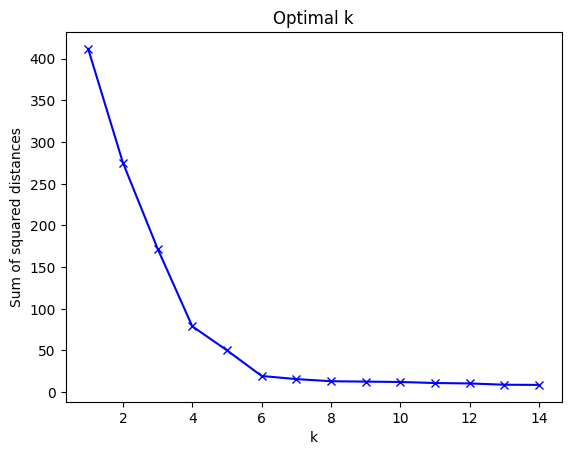

In [10]:
#3-33 적당한 K 값 추출
Sum_of_squared_distances = []
K = range(1, 15) # K값을 1에서 15까지 적용

for k in K:
    km = KMeans(n_clusters=k) #1~14의 K값 적용
    km = km.fit(data_transformed) #Kmeans 모델 훈련
    Sum_of_squared_distances.append(km.inertia_)

#거리의 제곱의 합(sum of squared distances, SSD)는 x, y 두 데이터의 차를 구해서 제곱한 값을 모두 더한 후 유사성을 측정하는 데 사용
#즉, 가장 가까운 클러스터 중심까지 거리를 제곱한 값의 합을 구할때 사용 ((x1, y1) - (x2, y2))^2을 전부 더한 값(-> 각 속한 클러스터의 중심점과의 거리의 제곱을 모두 더한)
#K가 증가하면 클러스터별 중심점이 많아지는 거여서 증가할 수록 0에 가까워짐 (샘플이 중심점이 되는)
#따라서 완만해진 K개수 이전이 맞음 (예시로는 K=5정도)
plt.plot(K, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum of squared distances')
plt.title('Optimal k')
plt.show()